# Bayesian Network Weather Forecasting
Uses the cleaned GSOD 2002 data to build, train, and query a Bayesian Network.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/gsod_2002.csv', low_memory=False)
print(f'Loaded {len(df):,} records with {df.shape[1]} columns')
df.head()

Loaded 2,788,413 records with 29 columns


,STN,WBAN,YEARMODA,TEMP,TEMP_CNT,DEWP,DEWP_CNT,SLP,SLP_CNT,STP,...,PRCP,SNDP,FRSHTT,DATE,FOG,RAIN,SNOW,HAIL,THUNDER,TORNADO
0,10010,99999,20020101,25.8,7,19.1,7,1005.8,7,1004.6,...,0.03,NaN,1000,2002-01-01,0,0,1,0,0,0
1,10010,99999,20020102,36.5,8,33.2,8,998.5,8,997.4,...,0.20,NaN,11000,2002-01-02,0,1,1,0,0,0
2,10010,99999,20020103,32.3,7,29.5,7,1001.2,7,1000.0,...,0.07,NaN,110000,2002-01-03,1,1,0,0,0,0
3,10010,99999,20020104,35.8,8,30.5,8,1011.2,8,1010.0,...,0.03,NaN,101000,2002-01-04,1,0,1,0,0,0
4,10010,99999,20020105,34.4,8,33.0,8,1003.1,8,1002.0,...,0.24,NaN,110000,2002-01-05,1,1,0,0,0,0


## Step 1 – Discretize Continuous Variables
Bayesian Networks require discrete states. We bin each continuous variable into meaningful weather categories.

In [6]:
disc = pd.DataFrame()

# TEMP (°F): cold < 32, warm > 75, else avg
disc['TEMP_D'] = pd.cut(
    df['TEMP'],
    bins=[-np.inf, 32, 75, np.inf],
    labels=['cold', 'avg', 'warm']
)

# SLP – sea-level pressure (mbar): low < 1005, high >= 1005
disc['SLP_D'] = pd.cut(
    df['SLP'],
    bins=[-np.inf, 1005, np.inf],
    labels=['low', 'high']
)

# WDSP – mean wind speed (knots): calm < 5, moderate < 15, strong >= 15
disc['WIND_D'] = pd.cut(
    df['WDSP'],
    bins=[-np.inf, 5, 15, np.inf],
    labels=['calm', 'moderate', 'strong']
)

# DEWP – dew point (°F): low < 32, moderate < 55, high >= 55
disc['DEWP_D'] = pd.cut(
    df['DEWP'],
    bins=[-np.inf, 32, 55, np.inf],
    labels=['low', 'moderate', 'high']
)

# PRCP – precipitation (inches): none = 0, light < 0.5, heavy >= 0.5
disc['PRCP_D'] = pd.cut(
    df['PRCP'].fillna(0),
    bins=[-np.inf, 0.0, 0.5, np.inf],
    labels=['none', 'light', 'heavy']
)

# Binary event flags (already 0/1)
disc['FOG']     = df['FOG'].astype(int)
disc['RAIN']    = df['RAIN'].astype(int)
disc['SNOW']    = df['SNOW'].astype(int)
disc['THUNDER'] = df['THUNDER'].astype(int)

# Drop rows with any remaining NaN (from continuous sentinels)
disc.dropna(inplace=True)

# Convert categoricals to string so pgmpy can consume them cleanly
for col in ['TEMP_D', 'SLP_D', 'WIND_D', 'DEWP_D', 'PRCP_D']:
    disc[col] = disc[col].astype(str)

print(f'Discretized dataset: {len(disc):,} rows')
print(disc.dtypes)
disc.head()

Discretized dataset: 1,912,679 rows
TEMP_D     object
SLP_D      object
WIND_D     object
DEWP_D     object
PRCP_D     object
FOG         int64
RAIN        int64
SNOW        int64
THUNDER     int64
dtype: object


,TEMP_D,SLP_D,WIND_D,DEWP_D,PRCP_D,FOG,RAIN,SNOW,THUNDER
0,cold,high,moderate,low,light,0,0,1,0
1,avg,low,strong,moderate,light,0,1,1,0
2,avg,low,moderate,low,light,1,1,0,0
3,avg,high,moderate,low,light,1,0,1,0
4,avg,low,moderate,moderate,light,1,1,0,0


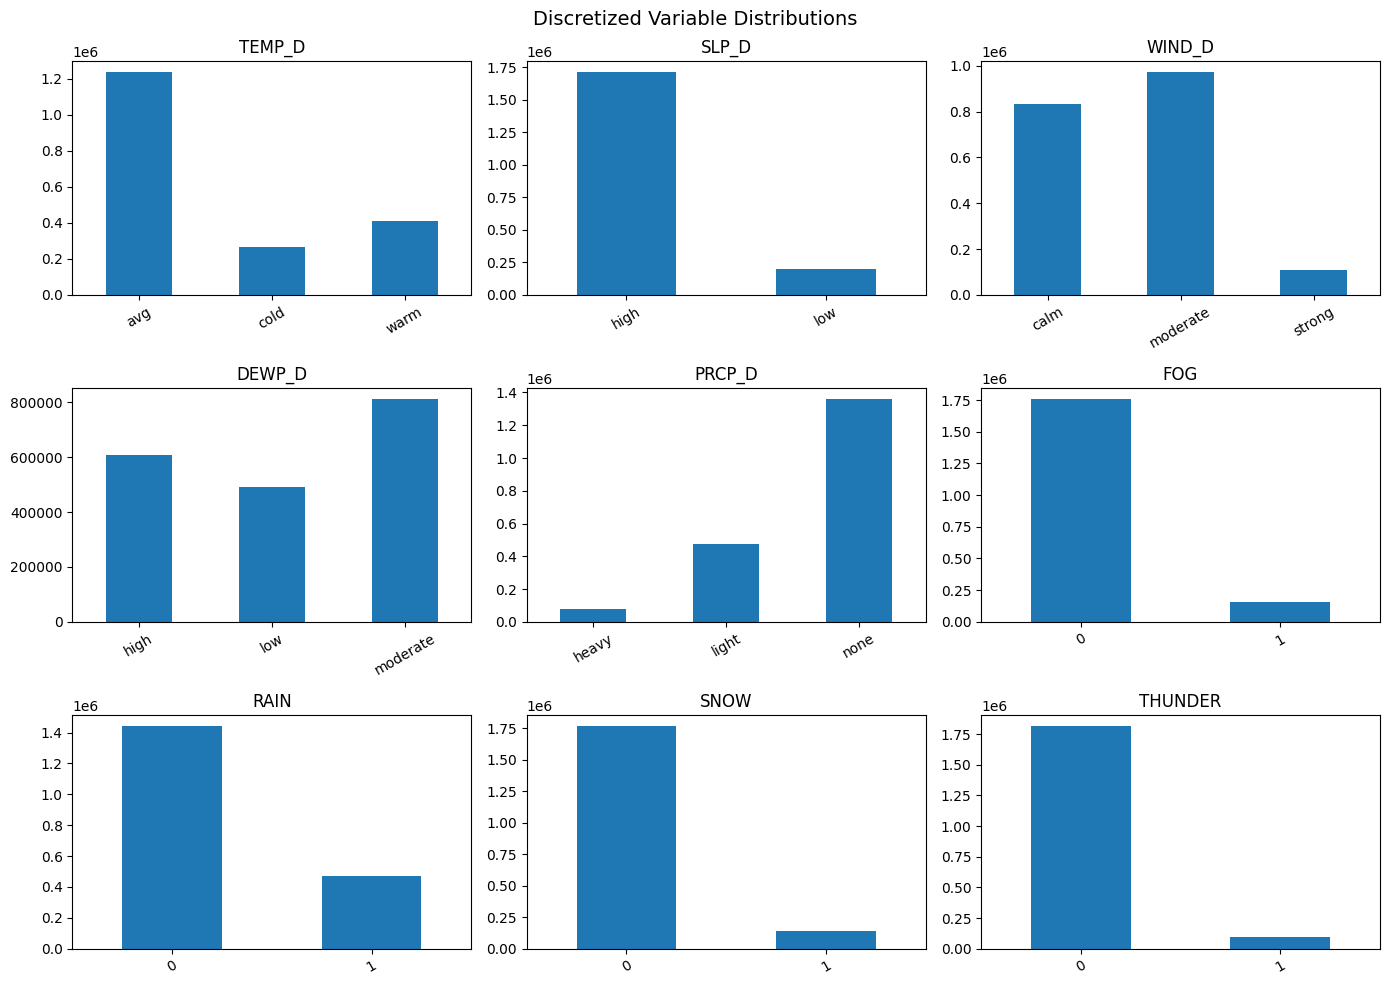

In [7]:
# Quick distribution check of discretized variables
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, disc.columns):
    disc[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

for ax in axes[len(disc.columns):]:
    ax.set_visible(False)

plt.suptitle('Discretized Variable Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Step 2 – Define the Network Structure (DAG)

Edge rationale (meteorological domain knowledge):
- **SLP → TEMP**: pressure systems drive temperature patterns
- **SLP → WIND**: pressure gradient creates wind
- **SLP → PRCP**: low pressure brings precipitation
- **TEMP → DEWP**: temperature controls dew-point proximity
- **TEMP → PRCP**: temperature determines rain vs snow
- **TEMP → SNOW**: cold required for snow
- **DEWP → FOG**: high dew point near temp → fog
- **DEWP → RAIN**: moisture content drives rain
- **PRCP → RAIN**: precipitation type
- **PRCP → SNOW**: precipitation type
- **WIND → FOG**: wind disperses fog
- **TEMP → THUNDER**: instability (warm + moisture) → thunder
- **DEWP → THUNDER**: humidity drives thunderstorm development

In [9]:
edges = [
    ('SLP_D',  'TEMP_D'),
    ('SLP_D',  'WIND_D'),
    ('SLP_D',  'PRCP_D'),
    ('TEMP_D', 'DEWP_D'),
    ('TEMP_D', 'PRCP_D'),
    ('TEMP_D', 'SNOW'),
    ('TEMP_D', 'THUNDER'),
    ('DEWP_D', 'FOG'),
    ('DEWP_D', 'RAIN'),
    ('DEWP_D', 'THUNDER'),
    ('PRCP_D', 'RAIN'),
    ('PRCP_D', 'SNOW'),
    ('WIND_D', 'FOG'),
]

model = DiscreteBayesianNetwork(edges)
print('Nodes:', model.nodes())
print('Edges:', model.edges())
# print('Valid DAG:', model.check_model() if hasattr(model, 'check_model') else 'use fit to validate')

Nodes: ['SLP_D', 'TEMP_D', 'WIND_D', 'PRCP_D', 'DEWP_D', 'SNOW', 'THUNDER', 'FOG', 'RAIN']
Edges: [('SLP_D', 'TEMP_D'), ('SLP_D', 'WIND_D'), ('SLP_D', 'PRCP_D'), ('TEMP_D', 'DEWP_D'), ('TEMP_D', 'PRCP_D'), ('TEMP_D', 'SNOW'), ('TEMP_D', 'THUNDER'), ('WIND_D', 'FOG'), ('PRCP_D', 'RAIN'), ('PRCP_D', 'SNOW'), ('DEWP_D', 'FOG'), ('DEWP_D', 'RAIN'), ('DEWP_D', 'THUNDER')]


## Step 3 – Train / Test Split and Parameter Learning

In [10]:
train_df, test_df = train_test_split(disc, test_size=0.2, random_state=42)
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

# Bayesian estimator with K2 (Dirichlet) prior to handle zero-count cells
model.fit(
    train_df,
    estimator=BayesianEstimator,
    prior_type='K2'
)

print('\nModel trained successfully.')
print('CPD nodes:', [cpd.variable for cpd in model.cpds])

Train: 1,530,143  |  Test: 382,536


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'TEMP_D': 'C', 'SLP_D': 'C', 'WIND_D': 'C', 'DEWP_D': 'C', 'PRCP_D': 'C', 'FOG': 'N', 'RAIN': 'N', 'SNOW': 'N', 'THUNDER': 'N'}



Model trained successfully.
CPD nodes: ['SLP_D', 'TEMP_D', 'WIND_D', 'PRCP_D', 'DEWP_D', 'SNOW', 'THUNDER', 'FOG', 'RAIN']


In [11]:
# Inspect a few CPDs
for var in ['RAIN', 'SNOW', 'FOG']:
    cpd = model.get_cpds(var)
    print(cpd)
    print()

+---------+---------------------+-----+--------------------+
| DEWP_D  | DEWP_D(high)        | ... | DEWP_D(moderate)   |
+---------+---------------------+-----+--------------------+
| PRCP_D  | PRCP_D(heavy)       | ... | PRCP_D(none)       |
+---------+---------------------+-----+--------------------+
| RAIN(0) | 0.21631963984243108 | ... | 0.8531155536250928 |
+---------+---------------------+-----+--------------------+
| RAIN(1) | 0.7836803601575689  | ... | 0.1468844463749071 |
+---------+---------------------+-----+--------------------+

+---------+---------------------+-----+-----------------------+
| PRCP_D  | PRCP_D(heavy)       | ... | PRCP_D(none)          |
+---------+---------------------+-----+-----------------------+
| TEMP_D  | TEMP_D(avg)         | ... | TEMP_D(warm)          |
+---------+---------------------+-----+-----------------------+
| SNOW(0) | 0.9542691613638522  | ... | 0.9996225006052301    |
+---------+---------------------+-----+-----------------------+
| 

## Step 4 – Inference
Use Variable Elimination to query the model.

In [13]:
infer = VariableElimination(model)

scenarios = [
    {'label': 'Cold + Low Pressure',    'evidence': {'TEMP_D': 'cold', 'SLP_D': 'low'}},
    {'label': 'Warm + High Pressure',   'evidence': {'TEMP_D': 'warm', 'SLP_D': 'high'}},
    {'label': 'Avg Temp + Strong Wind', 'evidence': {'TEMP_D': 'avg',  'WIND_D': 'strong'}},
    {'label': 'High Dew + Low Pressure','evidence': {'DEWP_D': 'high', 'SLP_D': 'low'}},
]

query_vars = ['RAIN', 'SNOW', 'FOG', 'THUNDER']

for scenario in scenarios:
    print(f"=== {scenario['label']} ===")
    for var in query_vars:
        result = infer.query(variables=[var], evidence=scenario['evidence'], show_progress=False)
        p = result.values
        labels = result.state_names[var]
        probs = {str(l): round(float(v), 4) for l, v in zip(labels, p)}
        print(f'  {var}: {probs}')
    print()

=== Cold + Low Pressure ===
  RAIN: {'0': 0.8748, '1': 0.1252}
  SNOW: {'0': 0.5608, '1': 0.4392}
  FOG: {'0': 0.9333, '1': 0.0667}
  THUNDER: {'0': 0.9988, '1': 0.0012}

=== Warm + High Pressure ===
  RAIN: {'0': 0.7416, '1': 0.2584}
  SNOW: {'0': 0.9995, '1': 0.0005}
  FOG: {'0': 0.9173, '1': 0.0827}
  THUNDER: {'0': 0.8886, '1': 0.1114}

=== Avg Temp + Strong Wind ===
  RAIN: {'0': 0.7171, '1': 0.2829}
  SNOW: {'0': 0.9688, '1': 0.0312}
  FOG: {'0': 0.9636, '1': 0.0364}
  THUNDER: {'0': 0.9596, '1': 0.0404}

=== High Dew + Low Pressure ===
  RAIN: {'0': 0.6847, '1': 0.3153}
  SNOW: {'0': 0.9853, '1': 0.0147}
  FOG: {'0': 0.9255, '1': 0.0745}
  THUNDER: {'0': 0.8785, '1': 0.1215}



## Step 5 – Evaluation
Predict the most probable class for each test row and compare against actuals.

In [14]:
# Evidence variables (predictors) — everything except what we're predicting
EVIDENCE_COLS = ['SLP_D', 'TEMP_D', 'WIND_D', 'DEWP_D', 'PRCP_D']
TARGET_COLS   = ['RAIN', 'SNOW', 'FOG']

# Use a sample for speed if the test set is large
eval_df = test_df.sample(min(2000, len(test_df)), random_state=0).reset_index(drop=True)

predictions = {t: [] for t in TARGET_COLS}

for _, row in eval_df.iterrows():
    evidence = {col: row[col] for col in EVIDENCE_COLS if pd.notna(row[col])}
    for target in TARGET_COLS:
        try:
            q = infer.map_query(variables=[target], evidence=evidence, show_progress=False)
            predictions[target].append(q[target])
        except Exception:
            predictions[target].append(np.nan)

print('Evaluation complete.')

Evaluation complete.


=== RAIN ===
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1490
           1       0.67      0.64      0.65       510

    accuracy                           0.83      2000
   macro avg       0.77      0.76      0.77      2000
weighted avg       0.82      0.83      0.83      2000



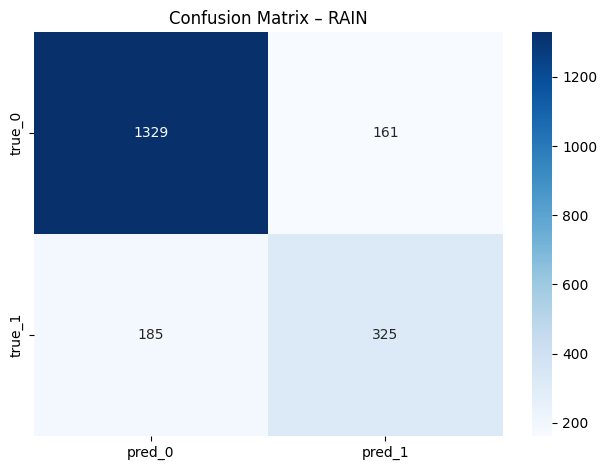


=== SNOW ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1840
           1       0.83      0.31      0.45       160

    accuracy                           0.94      2000
   macro avg       0.89      0.65      0.71      2000
weighted avg       0.93      0.94      0.93      2000



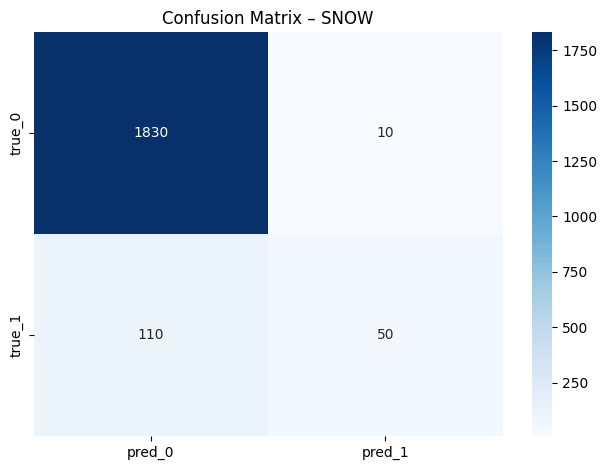


=== FOG ===
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1858
           1       0.00      0.00      0.00       142

    accuracy                           0.93      2000
   macro avg       0.46      0.50      0.48      2000
weighted avg       0.86      0.93      0.89      2000



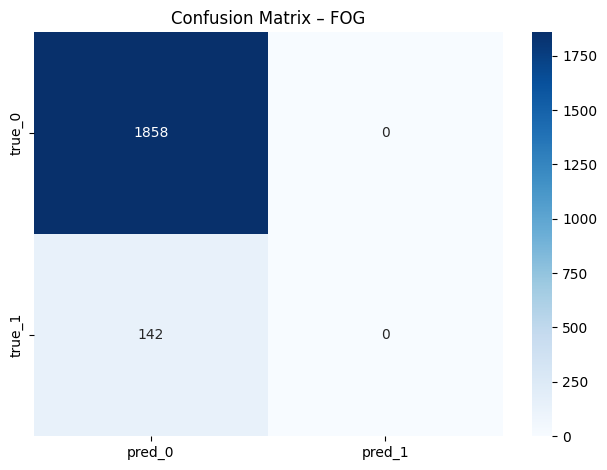

In [15]:
for target in TARGET_COLS:
    pred = pd.array(predictions[target])
    actual = eval_df[target].values

    # Drop rows where prediction failed
    mask = pd.notna(pred)
    pred   = pred[mask].astype(int)
    actual = actual[mask].astype(int)

    print(f'=== {target} ===')
    print(classification_report(actual, pred, zero_division=0))

    cm = confusion_matrix(actual, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'pred_{i}' for i in range(cm.shape[1])],
                yticklabels=[f'true_{i}' for i in range(cm.shape[0])])
    plt.title(f'Confusion Matrix – {target}')
    plt.tight_layout()
    plt.show()
    print()

## Next Steps
- **Structure learning**: Try `HillClimbSearch` or `PC` algorithm from `pgmpy.estimators` to data-drive the DAG
- **Dynamic Bayesian Network (DBN)**: Add a time slice (day *t−1* → day *t*) using `pgmpy.models.DynamicBayesianNetwork`
- **More years of data**: Extend beyond 2002 for better CPD estimates
- **Station filtering**: Focus on specific stations/regions instead of all global stations
- **Bin tuning**: Adjust cut-points using quantile-based binning if class imbalance is severe